# Explore Filtered and Cleaned FireProtDB


**Objective:** Explore our already filtered FireProtDB database for the proteins that are most represented in the dataset.

**Broader Goal:** Want to provide Prof and Allan the following - 6-12 proteins in the dataset, 5 mutants each, associated delta delta G's and structures, include stabilizing + destabilizing pairs from the filtered dataset


**Author:** Shyam Chandra

**Date:** October 17, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Step 0: Load the Filtered Dataset

Loading the filtered FireProtDB dataset from `df_fireprot_median_ddG_old.csv`.

In [2]:
# Load dataset
data_path = Path("../707_Files_for_Colab/Data_Frames/df_fireprot_median_ddG_old.csv")
df = pd.read_csv(data_path)

print(f"Dataset loaded: {len(df)} mutations")
print(f"Unique proteins (by UniProt ID): {df['uniprot_id'].nunique()}")
print(f"Unique protein names: {df['protein_name'].nunique()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head(3)

Dataset loaded: 5086 mutations
Unique proteins (by UniProt ID): 174
Unique protein names: 158

Columns: ['experiment_id', 'protein_name', 'uniprot_id', 'pdb_id', 'chain', 'position', 'wild_type', 'mutation', 'ddG', 'sequence', 'is_in_catalytic_pocket', 'is_essential', 'mt_sequence']

First few rows:


,experiment_id,protein_name,uniprot_id,pdb_id,chain,position,wild_type,mutation,ddG,sequence,is_in_catalytic_pocket,is_essential,mt_sequence
0,PT017913,10 kDa chaperonin,P0A6F9,1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1...,A,3,I,C,0.4,MNIRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...,False,False,MNCRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...
1,PT017914,10 kDa chaperonin,P0A6F9,1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1...,A,3,I,W,0.4,MNIRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...,False,False,MNWRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...
2,VB01861,10 kDa chaperonin,P0A6F9,1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1AON|1...,A,48,I,W,0.2,MNIRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...,False,False,MNIRPLHDRVIVKRKEVETKSAGGIVLTGSAAAKSTRGEVLAVGNG...


# Step 1: Analyze ΔΔG Distribution

Check distribution of near-zero, stabilizing, and destabilizing mutations.

Overall ΔΔG Distribution:
stability_class
Destabilizing    2740
Near-zero        1641
Stabilizing       705
Name: count, dtype: int64

Percentages:
stability_class
Destabilizing    53.873378
Near-zero        32.265041
Stabilizing      13.861581
Name: proportion, dtype: float64


ΔΔG Summary Statistics:
count    5086.000000
mean        1.019707
std         1.806726
min       -13.700000
25%        -0.100000
50%         0.700000
75%         1.900000
max        17.400000
Name: ddG, dtype: float64


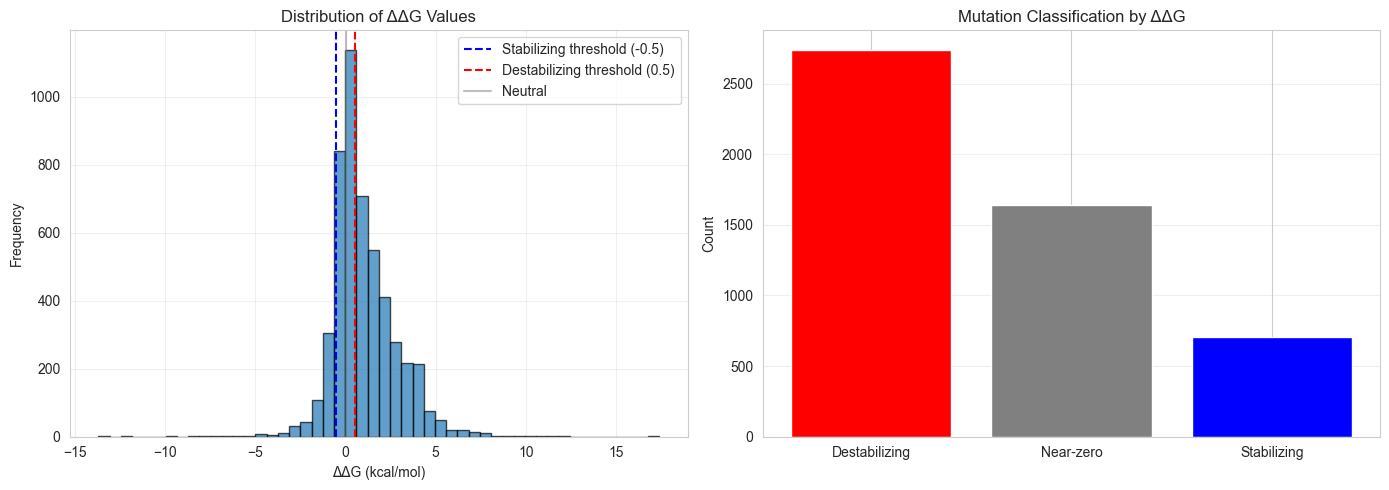


⚠️  NOTE: Only 13.9% are stabilizing (ΔΔG < -0.5)
   We'll aim for 3 stabilizing + 3 destabilizing per protein, but may need to adjust.


In [3]:
# Classify mutations by ddG threshold
threshold = 0.5

df['stability_class'] = pd.cut(df['ddG'], 
                                bins=[-np.inf, -threshold, threshold, np.inf],
                                labels=['Stabilizing', 'Near-zero', 'Destabilizing'])

# Overall distribution
print("Overall ΔΔG Distribution:")
print(df['stability_class'].value_counts())
print(f"\nPercentages:")
print(df['stability_class'].value_counts(normalize=True) * 100)

# Summary statistics
print(f"\n\nΔΔG Summary Statistics:")
print(df['ddG'].describe())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['ddG'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(-threshold, color='blue', linestyle='--', label=f'Stabilizing threshold ({-threshold})')
axes[0].axvline(threshold, color='red', linestyle='--', label=f'Destabilizing threshold ({threshold})')
axes[0].axvline(0, color='gray', linestyle='-', alpha=0.5, label='Neutral')
axes[0].set_xlabel('ΔΔG (kcal/mol)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of ΔΔG Values')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Bar chart of classes
stability_counts = df['stability_class'].value_counts()
colors = {'Stabilizing': 'blue', 'Near-zero': 'gray', 'Destabilizing': 'red'}
axes[1].bar(range(len(stability_counts)), stability_counts.values, 
           color=[colors[x] for x in stability_counts.index])
axes[1].set_xticks(range(len(stability_counts)))
axes[1].set_xticklabels(stability_counts.index)
axes[1].set_ylabel('Count')
axes[1].set_title('Mutation Classification by ΔΔG')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n⚠️  NOTE: Only {df[df['stability_class']=='Stabilizing'].shape[0]/len(df)*100:.1f}% are stabilizing (ΔΔG < -0.5)")
print(f"   We'll aim for 3 stabilizing + 3 destabilizing per protein, but may need to adjust.")

# Step 2: Identify Top 12 Most Frequent Wild-Type Proteins

Rank proteins by number of mutations in the dataset.

TOP 12 MOST REPRESENTED WILD-TYPE PROTEINS

Rank   UniProt ID   Mutations    Protein Name                            
--------------------------------------------------------------------------------
1      P06654       941          Immunoglobulin G-binding protein G      
2      P00644       579          Thermonuclease                          
3      P00720       308          Endolysin                               
4      P00648       176          Ribonuclease                            
5      P61626       133          Lysozyme C                              
6      P07751       119          Spectrin alpha chain, non-erythrocytic 1
7      P0ABQ4       111          Dihydrofolate reductase                 
8      P69543       92           DNA-Binding protein G5P                 
9      P01053       86           Subtilisin-chymotrypsin inhibitor-2A    
10     P0A7Y4       79           Ribonuclease HI                         
11     P02185       76           Myoglobin                   

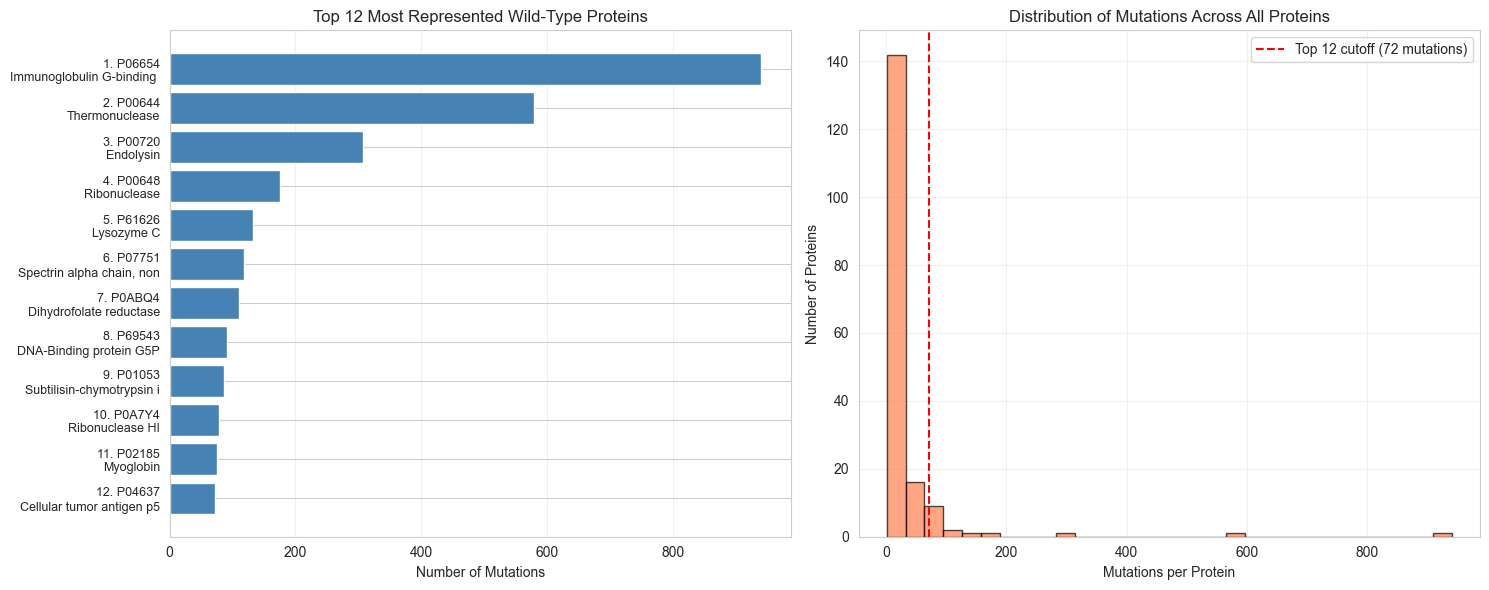


✓ Identified top 12 proteins with 2772 total mutations


In [4]:
# Count mutations per protein
protein_counts = df.groupby(['uniprot_id', 'protein_name']).size().reset_index(name='mutation_count')
protein_counts = protein_counts.sort_values('mutation_count', ascending=False).reset_index(drop=True)

# Get top 12
top_12 = protein_counts.head(12).copy()
top_12['rank'] = range(1, 13)

print("=" * 80)
print("TOP 12 MOST REPRESENTED WILD-TYPE PROTEINS")
print("=" * 80)
print(f"\n{'Rank':<6} {'UniProt ID':<12} {'Mutations':<12} {'Protein Name':<40}")
print("-" * 80)
for idx, row in top_12.iterrows():
    print(f"{row['rank']:<6} {row['uniprot_id']:<12} {row['mutation_count']:<12} {row['protein_name'][:40]:<40}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 12 bar chart
axes[0].barh(range(12), top_12['mutation_count'].values, color='steelblue')
axes[0].set_yticks(range(12))
axes[0].set_yticklabels([f"{row['rank']}. {row['uniprot_id']}\n{row['protein_name'][:25]}" 
                         for idx, row in top_12.iterrows()], fontsize=9)
axes[0].set_xlabel('Number of Mutations')
axes[0].set_title('Top 12 Most Represented Wild-Type Proteins')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Distribution of mutations across all proteins
axes[1].hist(protein_counts['mutation_count'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(top_12['mutation_count'].min(), color='red', linestyle='--', 
               label=f'Top 12 cutoff ({top_12["mutation_count"].min()} mutations)')
axes[1].set_xlabel('Mutations per Protein')
axes[1].set_ylabel('Number of Proteins')
axes[1].set_title('Distribution of Mutations Across All Proteins')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Store for later use
top_12_ids = top_12['uniprot_id'].tolist()
print(f"\n✓ Identified top 12 proteins with {top_12['mutation_count'].sum()} total mutations")

# Step 3: Check Availability of Wild-Type Structures

Verify which of the top 12 proteins have PDB structures in `WT_PDBs/`.

In [5]:
# Check for existing WT structures
wt_pdb_dir = Path("../707_Files_for_Colab/WT_PDBs")
available_pdbs = {p.stem for p in wt_pdb_dir.glob("*.pdb")}

print(f"Total PDB files in WT_PDBs/: {len(available_pdbs)}")
print("\nStructure Availability for Top 12 Proteins:")
print("-" * 80)
print(f"{'Rank':<6} {'UniProt ID':<12} {'Structure Available':<20} {'Status':<20}")
print("-" * 80)

top_12['has_structure'] = top_12['uniprot_id'].isin(available_pdbs)
structures_available = []

for idx, row in top_12.iterrows():
    has_pdb = row['uniprot_id'] in available_pdbs
    status = "✓ Available" if has_pdb else "✗ Needs Generation"
    structures_available.append(has_pdb)
    print(f"{row['rank']:<6} {row['uniprot_id']:<12} {str(has_pdb):<20} {status:<20}")

print("-" * 80)
print(f"\nSummary:")
print(f"  Structures Available: {sum(structures_available)}/12")
print(f"  Need Generation: {12 - sum(structures_available)}/12")

if 12 - sum(structures_available) > 0:
    missing = top_12[~top_12['has_structure']]['uniprot_id'].tolist()
    print(f"\n  Missing UniProt IDs: {', '.join(missing)}")

Total PDB files in WT_PDBs/: 162

Structure Availability for Top 12 Proteins:
--------------------------------------------------------------------------------
Rank   UniProt ID   Structure Available  Status              
--------------------------------------------------------------------------------
1      P06654       True                 ✓ Available         
2      P00644       True                 ✓ Available         
3      P00720       False                ✗ Needs Generation  
4      P00648       True                 ✓ Available         
5      P61626       True                 ✓ Available         
6      P07751       True                 ✓ Available         
7      P0ABQ4       True                 ✓ Available         
8      P69543       False                ✗ Needs Generation  
9      P01053       True                 ✓ Available         
10     P0A7Y4       True                 ✓ Available         
11     P02185       True                 ✓ Available         
12     P04637   

# Step 4: Select Mutants for Top 12 Proteins

For each protein, select up to 6 mutants: aim for 3 stabilizing + 3 destabilizing.

In [6]:
def select_mutants_for_protein(protein_df, n_stabilizing=3, n_destabilizing=3):
    """
    Select mutants for a protein, aiming for balanced stabilizing/destabilizing.
    
    Strategy:
    1. Try to get n_stabilizing stabilizing mutants (ddG < -0.5)
    2. Try to get n_destabilizing destabilizing mutants (ddG > 0.5)
    3. If not enough of one type, fill with the other type
    4. Prioritize mutants with larger |ddG| values (more extreme changes)
    """
    stabilizing = protein_df[protein_df['stability_class'] == 'Stabilizing'].copy()
    destabilizing = protein_df[protein_df['stability_class'] == 'Destabilizing'].copy()
    
    # Sort by absolute ddG value (most extreme first)
    stabilizing = stabilizing.sort_values('ddG', ascending=True)
    destabilizing = destabilizing.sort_values('ddG', ascending=False)
    
    # Select mutants
    selected_stabilizing = stabilizing.head(n_stabilizing)
    selected_destabilizing = destabilizing.head(n_destabilizing)
    
    # Check if we have enough
    n_stab_selected = len(selected_stabilizing)
    n_destab_selected = len(selected_destabilizing)
    
    # Fill in if needed
    total_needed = n_stabilizing + n_destabilizing
    total_selected = n_stab_selected + n_destab_selected
    
    if total_selected < total_needed:
        deficit = total_needed - total_selected
        
        # Try to fill from the other category
        if n_stab_selected < n_stabilizing:
            # Need more stabilizing, take extra destabilizing
            extra_destab = destabilizing.iloc[n_destab_selected:n_destab_selected + deficit]
            selected_destabilizing = pd.concat([selected_destabilizing, extra_destab])
        elif n_destab_selected < n_destabilizing:
            # Need more destabilizing, take extra stabilizing
            extra_stab = stabilizing.iloc[n_stab_selected:n_stab_selected + deficit]
            selected_stabilizing = pd.concat([selected_stabilizing, extra_stab])
    
    selected = pd.concat([selected_stabilizing, selected_destabilizing])
    
    return selected, n_stab_selected, n_destab_selected

# Select mutants for each of the top 12 proteins
selected_mutants_list = []
selection_summary = []

print("=" * 100)
print("MUTANT SELECTION FOR TOP 12 PROTEINS")
print("=" * 100)

for idx, protein_row in top_12.iterrows():
    uniprot_id = protein_row['uniprot_id']
    protein_name = protein_row['protein_name']
    rank = protein_row['rank']
    
    # Get all mutations for this protein
    protein_mutations = df[df['uniprot_id'] == uniprot_id].copy()
    
    # Select mutants
    selected, n_stab, n_destab = select_mutants_for_protein(protein_mutations)
    
    # Add protein info
    selected = selected.copy()
    selected['rank'] = rank
    
    selected_mutants_list.append(selected)
    
    # Summary
    summary = {
        'rank': rank,
        'uniprot_id': uniprot_id,
        'protein_name': protein_name,
        'total_mutations': len(protein_mutations),
        'n_stabilizing_available': len(protein_mutations[protein_mutations['stability_class'] == 'Stabilizing']),
        'n_destabilizing_available': len(protein_mutations[protein_mutations['stability_class'] == 'Destabilizing']),
        'n_stabilizing_selected': n_stab,
        'n_destabilizing_selected': n_destab,
        'total_selected': len(selected),
        'has_structure': protein_row['has_structure']
    }
    selection_summary.append(summary)
    
    print(f"\n{rank}. {protein_name} ({uniprot_id})")
    print(f"   Available: {summary['n_stabilizing_available']} stabilizing, {summary['n_destabilizing_available']} destabilizing")
    print(f"   Selected:  {n_stab} stabilizing, {n_destab} destabilizing (Total: {len(selected)})")
    print(f"   ΔΔG range: [{selected['ddG'].min():.2f}, {selected['ddG'].max():.2f}]")

# Combine all selected mutants
final_selection = pd.concat(selected_mutants_list, ignore_index=True)
selection_summary_df = pd.DataFrame(selection_summary)

print("\n" + "=" * 100)
print(f"TOTAL SELECTED: {len(final_selection)} mutants across 12 proteins")
print("=" * 100)

MUTANT SELECTION FOR TOP 12 PROTEINS

1. Immunoglobulin G-binding protein G (P06654)
   Available: 193 stabilizing, 337 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6)
   ΔΔG range: [-4.60, 4.00]

2. Thermonuclease (P00644)
   Available: 18 stabilizing, 383 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6)
   ΔΔG range: [-1.40, 7.70]

3. Endolysin (P00720)
   Available: 21 stabilizing, 184 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6)
   ΔΔG range: [-2.00, 9.70]

4. Ribonuclease (P00648)
   Available: 8 stabilizing, 124 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6)
   ΔΔG range: [-1.20, 8.40]

5. Lysozyme C (P61626)
   Available: 17 stabilizing, 67 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6)
   ΔΔG range: [-1.90, 4.60]

6. Spectrin alpha chain, non-erythrocytic 1 (P07751)
   Available: 13 stabilizing, 71 destabilizing
   Selected:  3 stabilizing, 3 destabilizing (Total: 6

# Step 5: Summary Tables and Visualizations


SELECTION SUMMARY TABLE
 Rank UniProt                             Protein Name  Stabilizing  Destabilizing  Total  Has WT Structure
    1  P06654       Immunoglobulin G-binding protein G            3              3      6              True
    2  P00644                           Thermonuclease            3              3      6              True
    3  P00720                                Endolysin            3              3      6             False
    4  P00648                             Ribonuclease            3              3      6              True
    5  P61626                               Lysozyme C            3              3      6              True
    6  P07751 Spectrin alpha chain, non-erythrocytic 1            3              3      6              True
    7  P0ABQ4                  Dihydrofolate reductase            3              3      6              True
    8  P69543                  DNA-Binding protein G5P            3              3      6             False
   

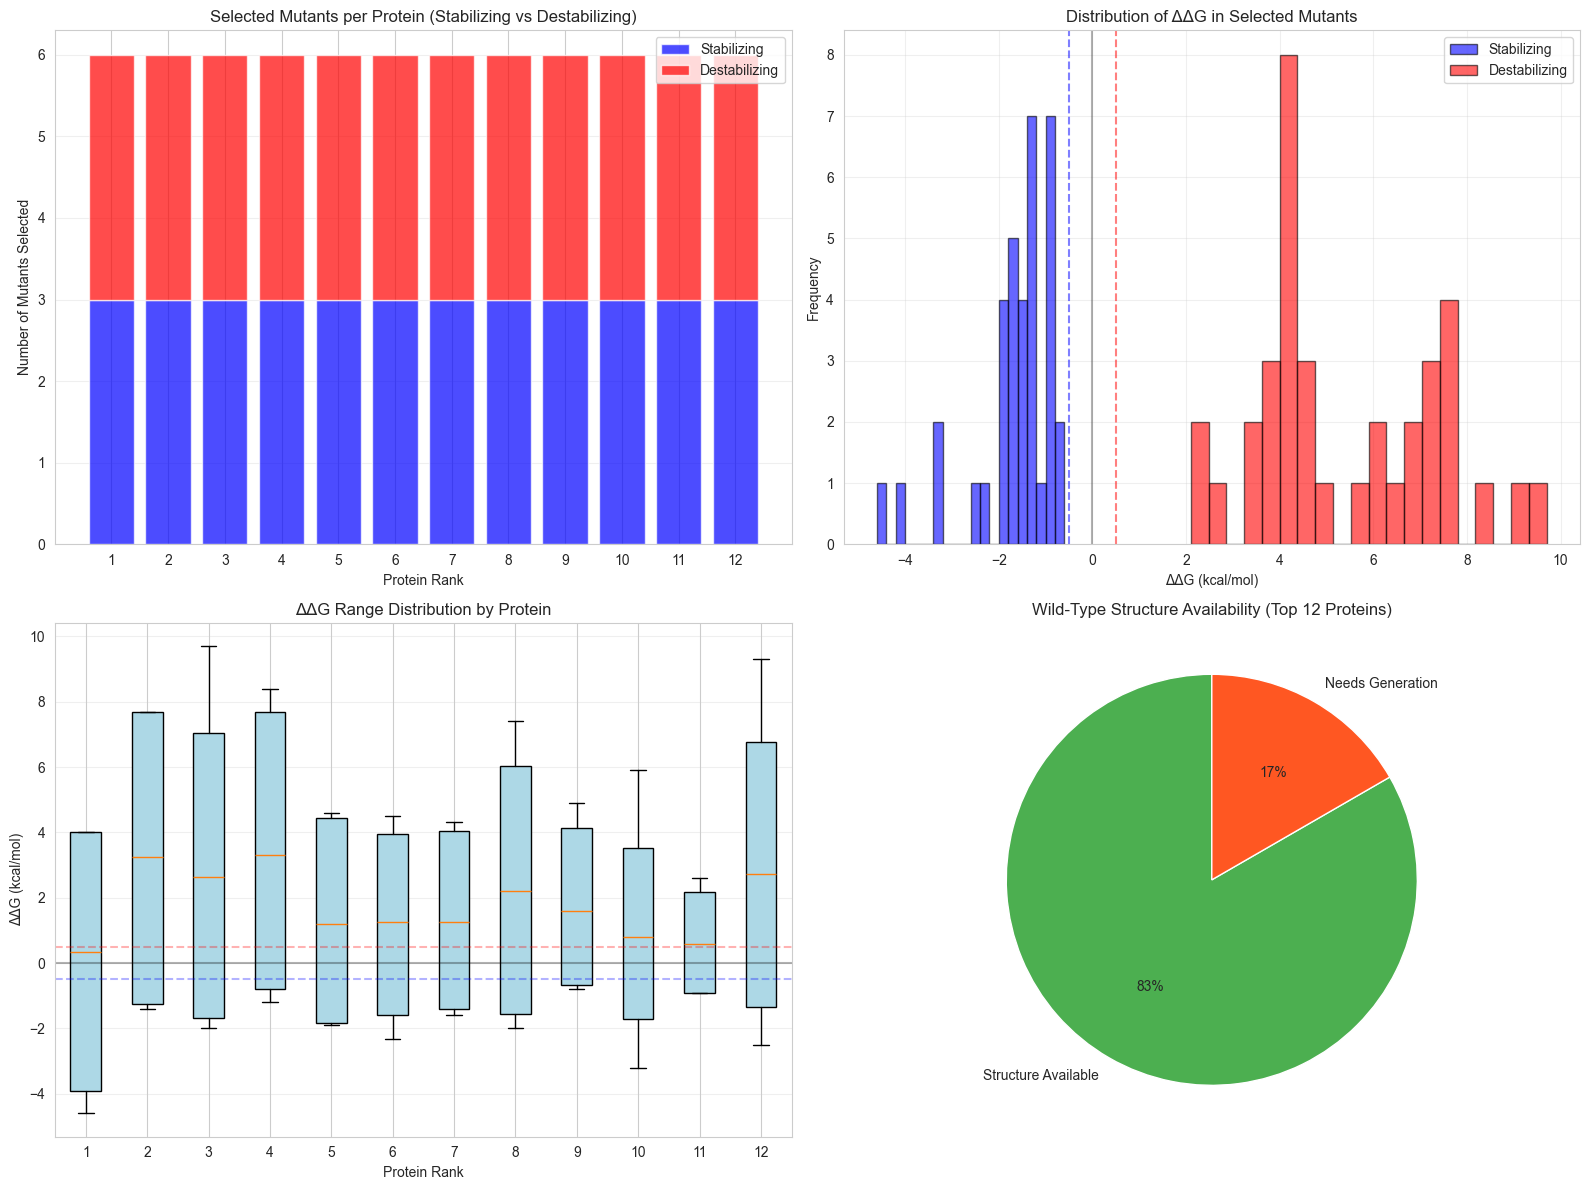


✓ Visualizations complete


In [7]:
# Display summary table
print("\nSELECTION SUMMARY TABLE")
print("=" * 120)
summary_display = selection_summary_df[[
    'rank', 'uniprot_id', 'protein_name', 
    'n_stabilizing_selected', 'n_destabilizing_selected', 'total_selected',
    'has_structure'
]].copy()
summary_display.columns = ['Rank', 'UniProt', 'Protein Name', 'Stabilizing', 'Destabilizing', 'Total', 'Has WT Structure']
print(summary_display.to_string(index=False))
print("=" * 120)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Stacked bar chart of selected mutants
ax1 = axes[0, 0]
x_pos = np.arange(len(selection_summary_df))
stab = selection_summary_df['n_stabilizing_selected'].values
destab = selection_summary_df['n_destabilizing_selected'].values

ax1.bar(x_pos, stab, label='Stabilizing', color='blue', alpha=0.7)
ax1.bar(x_pos, destab, bottom=stab, label='Destabilizing', color='red', alpha=0.7)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(selection_summary_df['rank'], rotation=0)
ax1.set_xlabel('Protein Rank')
ax1.set_ylabel('Number of Mutants Selected')
ax1.set_title('Selected Mutants per Protein (Stabilizing vs Destabilizing)')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. ΔΔG distribution of selected mutants
ax2 = axes[0, 1]
colors_map = {'Stabilizing': 'blue', 'Near-zero': 'gray', 'Destabilizing': 'red'}
for stability_class in ['Stabilizing', 'Destabilizing']:
    subset = final_selection[final_selection['stability_class'] == stability_class]
    if len(subset) > 0:
        ax2.hist(subset['ddG'], bins=20, alpha=0.6, label=stability_class, 
                color=colors_map[stability_class], edgecolor='black')
ax2.axvline(0, color='black', linestyle='-', alpha=0.3)
ax2.axvline(-0.5, color='blue', linestyle='--', alpha=0.5)
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('ΔΔG (kcal/mol)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of ΔΔG in Selected Mutants')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Box plot of ΔΔG by protein rank
ax3 = axes[1, 0]
ddg_by_protein = [final_selection[final_selection['rank'] == r]['ddG'].values 
                  for r in range(1, 13)]
bp = ax3.boxplot(ddg_by_protein, labels=range(1, 13), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax3.axhline(0, color='black', linestyle='-', alpha=0.3)
ax3.axhline(-0.5, color='blue', linestyle='--', alpha=0.3)
ax3.axhline(0.5, color='red', linestyle='--', alpha=0.3)
ax3.set_xlabel('Protein Rank')
ax3.set_ylabel('ΔΔG (kcal/mol)')
ax3.set_title('ΔΔG Range Distribution by Protein')
ax3.grid(axis='y', alpha=0.3)

# 4. Structure availability pie chart
ax4 = axes[1, 1]
structure_counts = selection_summary_df['has_structure'].value_counts()
colors = ['#4CAF50', '#FF5722']
labels = ['Structure Available', 'Needs Generation']
ax4.pie(structure_counts.values, labels=labels, autopct='%1.0f%%', 
       colors=colors, startangle=90)
ax4.set_title('Wild-Type Structure Availability (Top 12 Proteins)')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete")

# Step 6: Create Detailed Mutant List

In [8]:
# Create detailed output for each protein
print("\nDETAILED MUTANT LIST BY PROTEIN")
print("=" * 120)

for rank in range(1, 13):
    protein_mutants = final_selection[final_selection['rank'] == rank].copy()
    if len(protein_mutants) == 0:
        continue
    
    protein_info = selection_summary_df[selection_summary_df['rank'] == rank].iloc[0]
    
    print(f"\n{'='*120}")
    print(f"RANK {rank}: {protein_info['protein_name']}")
    print(f"UniProt ID: {protein_info['uniprot_id']}")
    print(f"WT Structure Available: {'Yes' if protein_info['has_structure'] else 'No (needs generation)'}")
    print(f"Total Mutants Selected: {len(protein_mutants)}")
    print(f"{'='*120}")
    
    # Display mutations
    display_cols = ['experiment_id', 'position', 'wild_type', 'mutation', 'ddG', 'stability_class']
    mutant_display = protein_mutants[display_cols].copy()
    mutant_display['mutation_notation'] = (protein_mutants['wild_type'] + 
                                           protein_mutants['position'].astype(str) + 
                                           protein_mutants['mutation'])
    
    print(f"\n{'Mutation':<10} {'Position':<10} {'WT→Mut':<10} {'ΔΔG':<12} {'Class':<15} {'Experiment ID':<15}")
    print("-" * 120)
    
    for idx, row in mutant_display.iterrows():
        mutation_str = f"{row['wild_type']}{row['position']}{row['mutation']}"
        wt_mut = f"{row['wild_type']}→{row['mutation']}"
        print(f"{mutation_str:<10} {row['position']:<10} {wt_mut:<10} {row['ddG']:<12.2f} {row['stability_class']:<15} {row['experiment_id']:<15}")

print("\n" + "=" * 120)
print("✓ Detailed mutant list complete")
print("=" * 120)


DETAILED MUTANT LIST BY PROTEIN

RANK 1: Immunoglobulin G-binding protein G
UniProt ID: P06654
WT Structure Available: Yes
Total Mutants Selected: 6

Mutation   Position   WT→Mut     ΔΔG          Class           Experiment ID  
------------------------------------------------------------------------------------------------------------------------
T349F      349        T→F        -4.60        Stabilizing     VB00963        
T349Y      349        T→Y        -4.10        Stabilizing     VB00969        
T349I      349        T→I        -3.30        Stabilizing     VB00965        
K257H      257        K→H        4.00         Destabilizing   LL000952       
A252Q      252        A→Q        4.00         Destabilizing   LL001423       
A252I      252        A→I        4.00         Destabilizing   LL001417       

RANK 2: Thermonuclease
UniProt ID: P00644
WT Structure Available: Yes
Total Mutants Selected: 6

Mutation   Position   WT→Mut     ΔΔG          Class           Experiment ID  
------

# Step 7: Export to CSV

Save the curated dataset for MIT Media Lab collaboration.

In [9]:
# Prepare export dataframe with all relevant information
export_df = final_selection.copy()

# Add mutation notation
export_df['mutation_notation'] = (export_df['wild_type'] + 
                                   export_df['position'].astype(str) + 
                                   export_df['mutation'])

# Add WT structure path
export_df['wt_structure_path'] = export_df.apply(
    lambda row: f"../707_Files_for_Colab/WT_PDBs/{row['uniprot_id']}.pdb" 
                if row['uniprot_id'] in available_pdbs else "NEEDS_GENERATION",
    axis=1
)

# Add mutant structure status
export_df['mutant_structure_status'] = "NEEDS_GENERATION"

# Reorder columns for clarity
export_cols = [
    'rank', 'protein_name', 'uniprot_id', 'pdb_id', 'chain',
    'mutation_notation', 'position', 'wild_type', 'mutation',
    'ddG', 'stability_class',
    'wt_structure_path', 'mutant_structure_status',
    'experiment_id', 'sequence', 'mt_sequence',
    'is_in_catalytic_pocket', 'is_essential'
]

export_df = export_df[export_cols]

# Sort by rank and ddG
export_df = export_df.sort_values(['rank', 'ddG']).reset_index(drop=True)

# Save to CSV
output_path = Path("mit_media_lab_selected_mutants.csv")
export_df.to_csv(output_path, index=False)

print(f"✓ Exported {len(export_df)} mutants to: {output_path}")
print(f"\nFile location: {output_path.absolute()}")

# Display first few rows as preview
print("\nPreview of exported data:")
print(export_df[['rank', 'protein_name', 'uniprot_id', 'mutation_notation', 'ddG', 'stability_class', 'wt_structure_path']].head(10))

# Summary statistics for export
print("\n" + "=" * 80)
print("EXPORT SUMMARY")
print("=" * 80)
print(f"Total proteins: {export_df['uniprot_id'].nunique()}")
print(f"Total mutants: {len(export_df)}")
print(f"  - Stabilizing: {len(export_df[export_df['stability_class'] == 'Stabilizing'])}")
print(f"  - Destabilizing: {len(export_df[export_df['stability_class'] == 'Destabilizing'])}")
print(f"  - Near-zero: {len(export_df[export_df['stability_class'] == 'Near-zero'])}")
print(f"\nWT structures available: {len(export_df[export_df['wt_structure_path'] != 'NEEDS_GENERATION']['uniprot_id'].unique())}/12")
print(f"Mutant structures to generate: {len(export_df)}")
print(f"\nΔΔG range: [{export_df['ddG'].min():.2f}, {export_df['ddG'].max():.2f}]")
print("=" * 80)

✓ Exported 72 mutants to: mit_media_lab_selected_mutants.csv

File location: /Users/shyamchandra/Desktop/BMI707FinalProject/Updates_for_MIT_Media_Lab_Collaboration/mit_media_lab_selected_mutants.csv

Preview of exported data:
   rank                        protein_name uniprot_id mutation_notation  ddG  \
0     1  Immunoglobulin G-binding protein G     P06654             T349F -4.6   
1     1  Immunoglobulin G-binding protein G     P06654             T349Y -4.1   
2     1  Immunoglobulin G-binding protein G     P06654             T349I -3.3   
3     1  Immunoglobulin G-binding protein G     P06654             K257H  4.0   
4     1  Immunoglobulin G-binding protein G     P06654             A252Q  4.0   
5     1  Immunoglobulin G-binding protein G     P06654             A252I  4.0   
6     2                      Thermonuclease     P00644             D103N -1.4   
7     2                      Thermonuclease     P00644             H206L -1.3   
8     2                      Thermonuclease  

# Next Steps

**For MIT Media Lab Collaboration:**

1. **Structure Generation Needed:**
   - Wild-type structures: Check which of the top 12 need generation
   - Mutant structures: All selected mutants require structure prediction
   - Recommended tools: AlphaFold2, ESMFold, or similar

2. **Quality Control:**
   - Verify WT structures align with PDB chains specified
   - Validate mutant generation at correct positions
   - Check structural integrity after mutation

3. **Final Deliverable Preparation:**
   - Once structures are generated, create comprehensive PKL file
   - Include: protein data, sequences, structures, ΔΔG values, metadata
   - Organize for easy downstream analysis

4. **Dataset Characteristics:**
   - Balanced mix of stabilizing and destabilizing mutations
   - Representative proteins from FireProtDB filtered set
   - Covers diverse protein types and mutation effects